# Sliced Latin Hypercube Design

A Latin Hypercube Design (LHD) is a space-filling sampling plan where each input dimension is divided into $n$ equal intervals with exactly one point per interval, ensuring perfect marginal uniformity in every dimension.

**Sliced LHDs** partition the $n = t \cdot m$ runs into $t$ equally-sized slices of $m$ points each, such that both the full design and every individual slice are valid LHDs. This makes them useful for computer experiments with a qualitative factor (e.g. code version, material type), or for sequential batches where each batch of $m$ runs must be space-filling on its own.

`sliced_lhd` returns a list of $t$ arrays (one per slice, each $m \times k$). Two orthogonal choices are available:

- **Grid vs. scrambled** — grid places points at regular midpoints $(i - 0.5)/n$ within their stratum; scrambled applies random within-stratum jitter, breaking the lattice structure and improving multi-dimensional coverage
- **Optimized vs. random** — `optimization='sa'` uses simulated annealing to minimise the average reciprocal distance criterion $\phi$ (lower = better); `optimization=None` (default) uses a random construction with no further optimisation

In [1]:
import sys
from pathlib import Path

_root = Path.cwd()
if (_root / "gethypercube").is_dir():
    pass
elif (_root.parent / "gethypercube").is_dir():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

from scipy.stats import qmc

%load_ext autoreload
%autoreload 2

from gethypercube import sliced_lhd, compute_phi, ks_test_uniform, lhs_degree, scale_LH

plt.rcParams["figure.facecolor"] = "white"

In [2]:
# ── Design helpers ─────────────────────────────────────────────────────────────

def design_vars(slices):
    """Full continuous design (n, k) and 1-based integer slice IDs."""
    X = np.vstack(slices)
    t, m = len(slices), len(slices[0])
    slice_ids = np.repeat(np.arange(1, t + 1), m)
    return X, slice_ids


# ── Discrepancy ────────────────────────────────────────────────────────────────

def star_discrepancy(X):
    n = len(X)
    worst = 0.0
    for i in range(n):
        empirical = np.mean(np.all(X <= X[i], axis=1))
        expected = np.prod(X[i])
        worst = max(worst, abs(empirical - expected))
    return worst


def centered_discrepancy(X):
    n, k = X.shape
    z = X - 0.5
    t1 = (13.0 / 12.0) ** k
    t2 = (2.0 / n) * np.sum(np.prod(1.0 + 0.5 * np.abs(z) - 0.5 * z**2, axis=1))
    zi = z[:, None, :]
    zl = z[None, :, :]
    t3 = (1.0 / n**2) * np.sum(
        np.prod(1.0 + 0.5 * np.abs(zi) + 0.5 * np.abs(zl) - 0.5 * np.abs(zi - zl), axis=2)
    )
    return float(np.sqrt(t1 - t2 + t3))


# ── Statistics ─────────────────────────────────────────────────────────────────

def slhd_stats(slices):
    """Compute stats for an SLHD given as a list of slice arrays."""
    X, slice_ids = design_vars(slices)
    t, m = len(slices), len(slices[0])
    ks_full_stats = [s for s, _ in ks_test_uniform(X)]
    ks_slice_all = [
        v for s in range(1, t + 1)
        for v, _ in ks_test_uniform(X[slice_ids == s])
    ]
    return {
        "phi":           compute_phi(X, r=15),
        "lhs_degree":    lhs_degree(X),
        "ks_full_mean":  float(np.mean(ks_full_stats)),
        "ks_full_max":   float(max(ks_full_stats)),
        "ks_slice_mean": float(np.mean(ks_slice_all)),
        "ks_slice_max":  float(max(ks_slice_all)),
        "d_star":        star_discrepancy(X),
        "cd":            centered_discrepancy(X),
    }


def print_slhd_stats(slices, label=""):
    s = slhd_stats(slices)
    t, m = len(slices), len(slices[0])
    k = slices[0].shape[1]
    print(f"{label}  n={t * m}  t={t}  k={k}")
    print(f"  phi={s['phi']:.4f}  LHS_degree={s['lhs_degree']:.4f}")
    print(f"  KS_full  mean={s['ks_full_mean']:.4f}  max={s['ks_full_max']:.4f}")
    print(f"  KS_slice mean={s['ks_slice_mean']:.4f}  max={s['ks_slice_max']:.4f}")
    print(f"  D*={s['d_star']:.4f}  CD={s['cd']:.4f}")


# ── Scatter plot ───────────────────────────────────────────────────────────────

def plot_scatter_grid(options, title=""):
    """2×2 scatter grid for k=2 sliced designs. options: list of dicts with 'label', 'slices'."""
    n_opts = len(options)
    n_cols = min(2, n_opts)
    n_rows = (n_opts + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), squeeze=False)
    axes = axes.flatten()
    for idx, opt in enumerate(options):
        ax = axes[idx]
        slices = opt["slices"]
        X, slice_ids = design_vars(slices)
        t = len(slices)
        colors = plt.cm.Set1(np.linspace(0, 0.8, t))
        for s in range(1, t + 1):
            mask = slice_ids == s
            ax.scatter(X[mask, 0], X[mask, 1], s=55, c=[colors[s - 1]],
                       edgecolors="white", linewidths=1.0, label=f"Slice {s}", zorder=3)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal")
        ax.legend(loc="upper left", fontsize=7)
        phi = slhd_stats(slices)["phi"]
        ax.set_title(f"{opt['label']}\nphi = {phi:.4f}")
        ax.grid(True, alpha=0.2)
    for idx in range(n_opts, len(axes)):
        axes[idx].set_visible(False)
    if title:
        fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


# ── Marginal uniformity ────────────────────────────────────────────────────────

def plot_marginal_uniformity_combined(options, k, title="Marginal uniformity — full design"):
    """Overlay all options' full-design empirical CDFs (one subplot per dimension)."""
    _auto = [
        ("black",   ":",  1.5),
        ("black",   "-.", 1.2),
        ("black",   "--", 2.0),
        ("black",   "-",  2.0),
        ("#e05252", "-",  1.8),
    ]
    fig, ax = plt.subplots(1, k, figsize=(3.5 * k, 3.5), sharey=True)
    ax = np.atleast_1d(ax)
    xx = np.linspace(0, 1, 100)
    for oi, opt in enumerate(options):
        X, _ = design_vars(opt["slices"])
        n = len(X)
        color = opt.get("color", _auto[oi][0])
        ls    = opt.get("ls",    _auto[oi][1])
        lw    = opt.get("lw",    _auto[oi][2])
        for j in range(k):
            sorted_vals = np.sort(X[:, j])
            emp_y = np.arange(1, n + 1, dtype=float) / n
            ax[j].plot(sorted_vals, emp_y, color=color, lw=lw, ls=ls,
                       label=opt["label"] if j == 0 else None)
    for j in range(k):
        ax[j].plot(xx, xx, color="#9ca3af", lw=1.2, ls="--",
                   label="U(0,1)" if j == 0 else None)
        ax[j].set_xlim(-0.02, 1.02)
        ax[j].set_ylim(-0.02, 1.02)
        ax[j].set_aspect("equal")
        ax[j].grid(True, alpha=0.3)
        ax[j].set_title(f"$x_{{{j + 1}}}$", fontsize=10)
        ax[j].set_xlabel("$x$")
    ax[0].set_ylabel("CDF")
    ax[0].legend(loc="lower right", fontsize=7)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_per_slice_uniformity(slices, title_prefix=""):
    """Per-slice marginal uniformity: (t x k) grid of empirical vs U(0,1) CDFs."""
    X, slice_ids = design_vars(slices)
    t, m, k = len(slices), len(slices[0]), slices[0].shape[1]
    fig, ax = plt.subplots(t, k, figsize=(3 * k, 2.5 * t),
                           sharex=True, sharey=True, squeeze=False)
    xx = np.linspace(0, 1, 100)
    for s in range(1, t + 1):
        xs = X[slice_ids == s]
        ks = ks_test_uniform(xs)
        for j in range(k):
            a = ax[s - 1, j]
            sorted_vals = np.sort(xs[:, j])
            emp_y = np.arange(1, m + 1, dtype=float) / m
            a.plot(sorted_vals, emp_y, color="#2563eb", lw=1.8)
            a.plot(xx, xx, color="#9ca3af", lw=1.2, ls="--")
            a.set_xlim(-0.02, 1.02)
            a.set_ylim(-0.02, 1.02)
            a.set_aspect("equal")
            a.grid(True, alpha=0.3)
            a.set_title(f"Slice {s} $\\cdot$ $x_{{{j + 1}}}$\nKS={ks[j][0]:.3f}", fontsize=8)
            if j == 0:
                a.set_ylabel("CDF")
    plt.setp(ax[-1, :], xlabel="$x$")
    fig.suptitle(f"{title_prefix}Per-slice marginal uniformity", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

### Small Design — Visualizing Slice Structure

Below we build four $n=40$ designs ($t=4$ slices, $m=10$ points per slice, $k=2$ dimensions). Each slice is shown in a distinct color; a well-optimized SLHD has slices that individually tile $[0,1]^2$ while jointly forming a single space-filling LHD.

| Configuration | Construction |
|---|---|
| **grid** | `sliced_lhd(scramble=False)`: midpoint placement, no optimization |
| **scrambled** | `sliced_lhd(scramble=True)`: random within-stratum jitter, no optimization |
| **grid + optimized** | `sliced_lhd(optimization='sa', scramble=False)`: midpoints + simulated annealing |
| **scrambled + optimized** | `sliced_lhd(optimization='sa', scramble=True)`: jittered + simulated annealing |

In [3]:
t_small, m_small, k_small = 4, 10, 2

slices_grid     = sliced_lhd(t=t_small, m=m_small, k=k_small, seed=42, scramble=False)
slices_scram    = sliced_lhd(t=t_small, m=m_small, k=k_small, seed=42, scramble=True)
slices_grid_opt = sliced_lhd(t=t_small, m=m_small, k=k_small, optimization='sa', seed=42,
                              scramble=False, total_iter=100_000)
slices_scram_opt = sliced_lhd(t=t_small, m=m_small, k=k_small, optimization='sa', seed=42,
                               scramble=True, total_iter=100_000)

small_options = [
    {"label": "grid",                 "slices": slices_grid,     "color": "black", "ls": ":",  "lw": 1.5},
    {"label": "scrambled",            "slices": slices_scram,    "color": "black", "ls": "--", "lw": 2.0},
    {"label": "grid + optimized",     "slices": slices_grid_opt, "color": "black", "ls": "-.", "lw": 1.2},
    {"label": "scrambled + optimized","slices": slices_scram_opt,"color": "black", "ls": "-",  "lw": 2.0},
]

for opt in small_options:
    print_slhd_stats(opt["slices"], opt["label"])

grid  n=40  t=4  k=2
  phi=20.2005  LHS_degree=1.0000
  KS_full  mean=0.0125  max=0.0125
  KS_slice mean=0.0875  max=0.0875
  D*=0.0905  CD=0.0331
scrambled  n=40  t=4  k=2
  phi=40.9834  LHS_degree=1.0000
  KS_full  mean=0.0244  max=0.0245
  KS_slice mean=0.0936  max=0.0994
  D*=0.0930  CD=0.0348
grid + optimized  n=40  t=4  k=2
  phi=12.6086  LHS_degree=1.0000
  KS_full  mean=0.0125  max=0.0125
  KS_slice mean=0.0875  max=0.0875
  D*=0.0630  CD=0.0212
scrambled + optimized  n=40  t=4  k=2
  phi=16.9573  LHS_degree=1.0000
  KS_full  mean=0.0246  max=0.0248
  KS_slice mean=0.0918  max=0.0993
  D*=0.0633  CD=0.0230


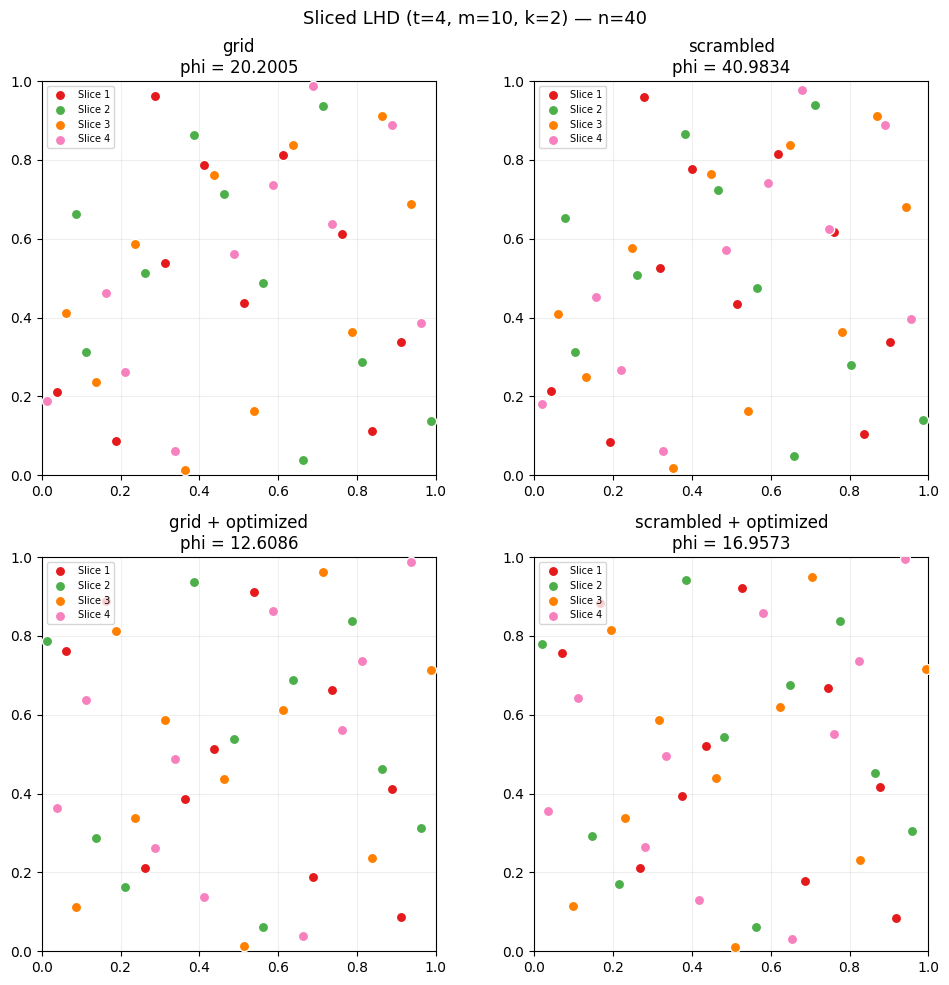

In [4]:
plot_scatter_grid(small_options, title="Sliced LHD (t=4, m=10, k=2) — n=40")

### Big Design — Statistics (n=400, k=3)

Scaling up to $n = 400$ runs ($t=4$ slices, $m=100$ per slice, $k=3$ dimensions). All four configurations are evaluated via:

- **$\phi$** — maximin criterion (lower = better spread); the objective that `sliced_lhd(optimization='sa')` optimises
- **LHS degree** — fraction of $n$ strata occupied per dimension; 1.0 means every stratum is covered exactly once (perfect LHD)
- **KS statistic** — Kolmogorov–Smirnov distance from $U(0,1)$ per column; lower = more uniform marginals; checked for the full design and separately for each slice
- **Star discrepancy** $D^*$ — maximum pointwise deviation of the empirical CDF from the product uniform; benchmark $\sqrt{k/n}$
- **Centered discrepancy** CD — weighted $L_2$ distance from the centered uniform; lower is better

In [5]:
t_big, m_big, k_big = 4, 100, 3
t0 = time.time()

slices_big_grid     = sliced_lhd(t=t_big, m=m_big, k=k_big, seed=17, scramble=False)
slices_big_scram    = sliced_lhd(t=t_big, m=m_big, k=k_big, seed=17, scramble=True)
slices_big_grid_opt = sliced_lhd(t=t_big, m=m_big, k=k_big, optimization='sa', seed=17,
                                  scramble=False, total_iter=500_000)
slices_big_scram_opt = sliced_lhd(t=t_big, m=m_big, k=k_big, optimization='sa', seed=17,
                                   scramble=True, total_iter=500_000)
print(f"Elapsed: {time.time() - t0:.1f}s")

big_options = [
    {"label": "grid",                 "slices": slices_big_grid,     "color": "black", "ls": ":",  "lw": 1.5},
    {"label": "scrambled",            "slices": slices_big_scram,    "color": "black", "ls": "--", "lw": 2.0},
    {"label": "grid + optimized",     "slices": slices_big_grid_opt, "color": "black", "ls": "-.", "lw": 1.2},
    {"label": "scrambled + optimized","slices": slices_big_scram_opt,"color": "black", "ls": "-",  "lw": 2.0},
]

Elapsed: 262.4s


In [6]:
for opt in big_options:
    print_slhd_stats(opt["slices"], opt["label"])
    print()

grid  n=400  t=4  k=3
  phi=41.2230  LHS_degree=1.0000
  KS_full  mean=0.0013  max=0.0013
  KS_slice mean=0.0088  max=0.0088
  D*=0.0279  CD=0.0159

scrambled  n=400  t=4  k=3
  phi=40.8619  LHS_degree=1.0000
  KS_full  mean=0.0025  max=0.0025
  KS_slice mean=0.0100  max=0.0100
  D*=0.0281  CD=0.0160

grid + optimized  n=400  t=4  k=3
  phi=15.1398  LHS_degree=1.0000
  KS_full  mean=0.0013  max=0.0013
  KS_slice mean=0.0088  max=0.0088
  D*=0.0270  CD=0.0182

scrambled + optimized  n=400  t=4  k=3
  phi=15.5122  LHS_degree=1.0000
  KS_full  mean=0.0025  max=0.0025
  KS_slice mean=0.0100  max=0.0100
  D*=0.0276  CD=0.0183



In [7]:
rows = []
for opt in big_options:
    s = slhd_stats(opt["slices"])
    rows.append({"method": opt["label"], **s})

df = pd.DataFrame(rows).set_index("method")
df[["phi", "lhs_degree", "ks_full_mean", "ks_full_max",
    "ks_slice_mean", "ks_slice_max", "d_star", "cd"]].round(4)

,phi,lhs_degree,ks_full_mean,ks_full_max,ks_slice_mean,ks_slice_max,d_star,cd
method,,,,,,,,
grid,41.2230,1.0,0.0013,0.0013,0.0088,0.0088,0.0279,0.0159
scrambled,40.8619,1.0,0.0025,0.0025,0.0100,0.0100,0.0281,0.0160
grid + optimized,15.1398,1.0,0.0013,0.0013,0.0088,0.0088,0.0270,0.0182
scrambled + optimized,15.5122,1.0,0.0025,0.0025,0.0100,0.0100,0.0276,0.0183


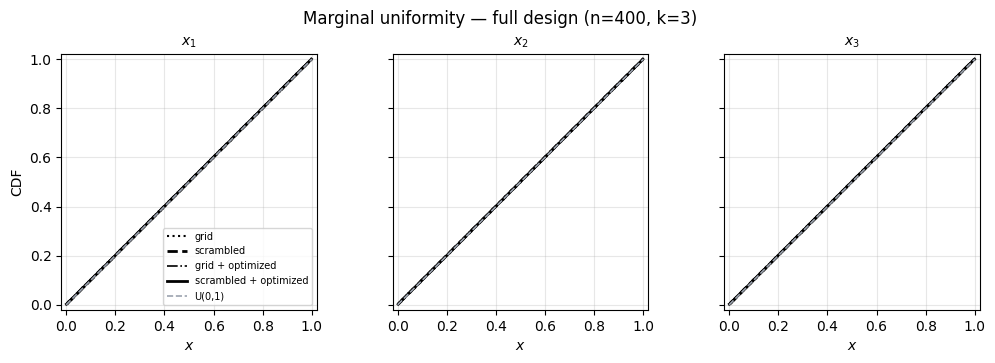

In [8]:
plot_marginal_uniformity_combined(
    big_options, k_big,
    title="Marginal uniformity — full design (n=400, k=3)"
)

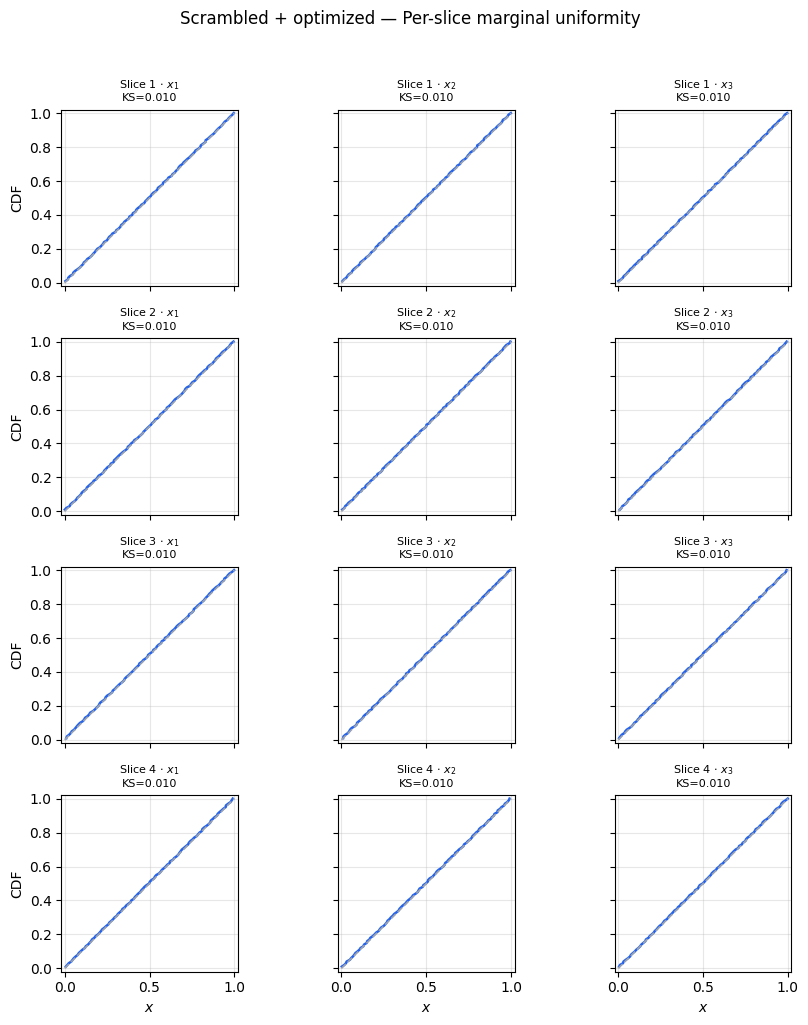

In [9]:
plot_per_slice_uniformity(slices_big_scram_opt, title_prefix="Scrambled + optimized — ")

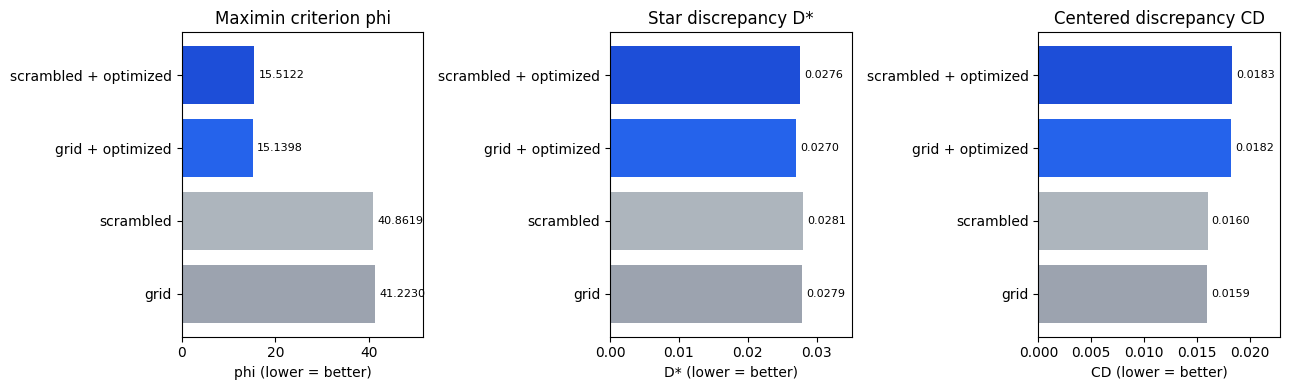

In [10]:
stats_list = [slhd_stats(opt["slices"]) for opt in big_options]
labels = [opt["label"] for opt in big_options]
bar_colors = ["#9ca3af", "#adb5bd", "#2563eb", "#1d4ed8"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

phis   = [s["phi"]   for s in stats_list]
dstars = [s["d_star"] for s in stats_list]
cds    = [s["cd"]    for s in stats_list]

for ax, vals, xlabel, title in zip(
    axes,
    [phis, dstars, cds],
    ["phi (lower = better)", "D* (lower = better)", "CD (lower = better)"],
    ["Maximin criterion phi", "Star discrepancy D*", "Centered discrepancy CD"],
):
    bars = ax.barh(labels, vals, color=bar_colors)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
    ax.set_xlim(0, max(vals) * 1.25)

plt.tight_layout()
plt.show()

### Sliced LHD vs. Divided Big LH vs. Concatenated Small LHs

The structural Sliced LHD guarantee — every slice is itself a valid LHD — is not free. Two naive alternatives require no special construction:

| Method | Description |
|--------|-------------|
| **Sliced LHD** | `sliced_lhd()`: all slices built jointly as a sliced structure |
| **Divided Big LH** | One big LHD of size $n = t \cdot m$; randomly partitioned into $t$ slices of $m$ points |
| **Concat. Small LHs** | $t$ independent LHDs of size $m$; stacked as slices |

Each method is evaluated under all four configurations. Metrics are shown for both the **full design** (all $n$ points) and the **per-slice average** (mean over $t$ slices). The per-slice metrics reveal whether slices are individually space-filling — only the Sliced LHD guarantees this by construction.

In [11]:
n_total = t_big * m_big   # 400

# ── Divided Big LH (4 options) ──────────────────────────────────────────────────
_rng_div       = np.random.default_rng(17)
_big_grid      = qmc.LatinHypercube(d=k_big, scramble=False, seed=17).random(n=n_total)
_big_scram     = qmc.LatinHypercube(d=k_big, scramble=True,  seed=17).random(n=n_total)
_big_grid_opt  = qmc.LatinHypercube(d=k_big, scramble=False, optimization="random-cd", seed=17).random(n=n_total)
_big_scram_opt = qmc.LatinHypercube(d=k_big, scramble=True,  optimization="random-cd", seed=17).random(n=n_total)

_perm = _rng_div.permutation(n_total)
_idxs = [_perm[s * m_big:(s + 1) * m_big] for s in range(t_big)]
div_grid      = [_big_grid[idx]      for idx in _idxs]
div_scram     = [_big_scram[idx]     for idx in _idxs]
div_grid_opt  = [_big_grid_opt[idx]  for idx in _idxs]
div_scram_opt = [_big_scram_opt[idx] for idx in _idxs]

# ── Concatenated Small LHs (4 options) ──────────────────────────────────────────
cat_grid      = [qmc.LatinHypercube(d=k_big, scramble=False, seed=17 + i).random(n=m_big)
                 for i in range(t_big)]
cat_scram     = [qmc.LatinHypercube(d=k_big, scramble=True,  seed=17 + i).random(n=m_big)
                 for i in range(t_big)]
cat_grid_opt  = [qmc.LatinHypercube(d=k_big, scramble=False, optimization="random-cd", seed=17 + i).random(n=m_big)
                 for i in range(t_big)]
cat_scram_opt = [qmc.LatinHypercube(d=k_big, scramble=True,  optimization="random-cd", seed=17 + i).random(n=m_big)
                 for i in range(t_big)]

print("Generated all comparison variants.")

Generated all comparison variants.


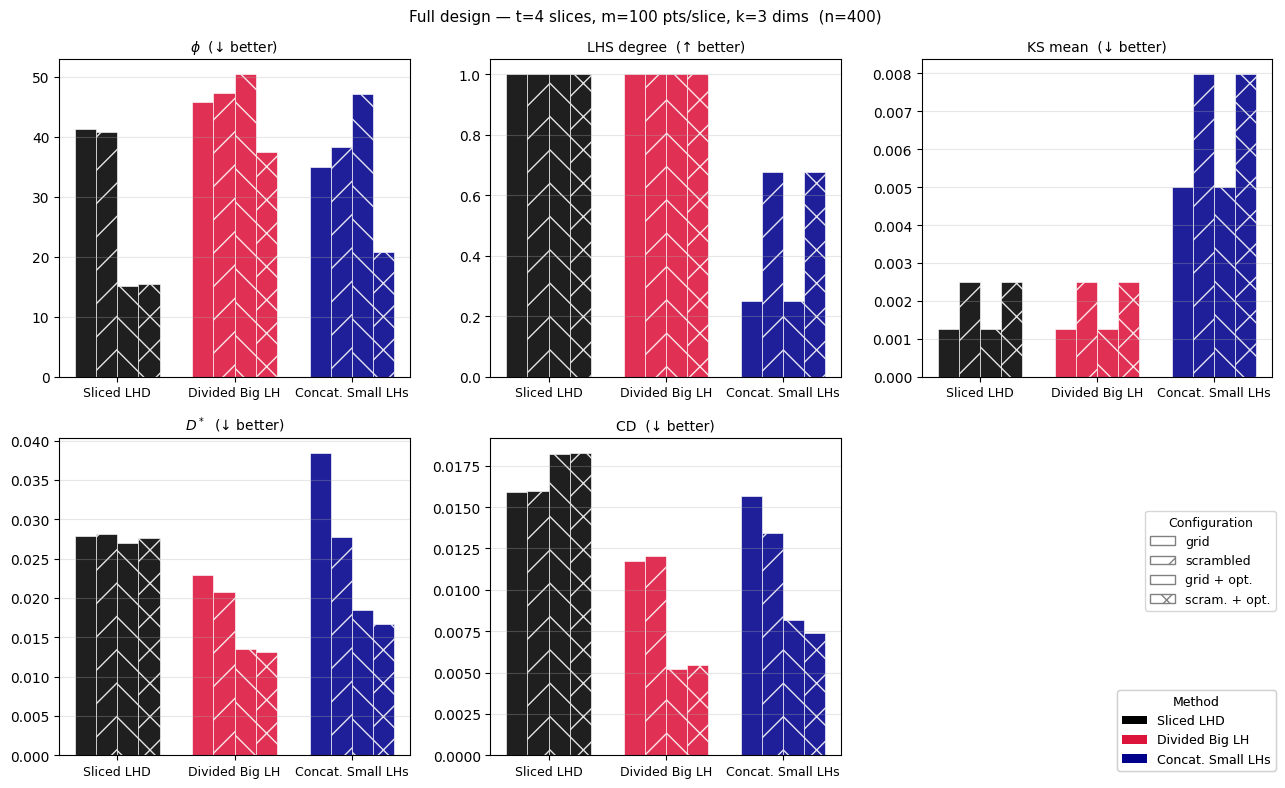

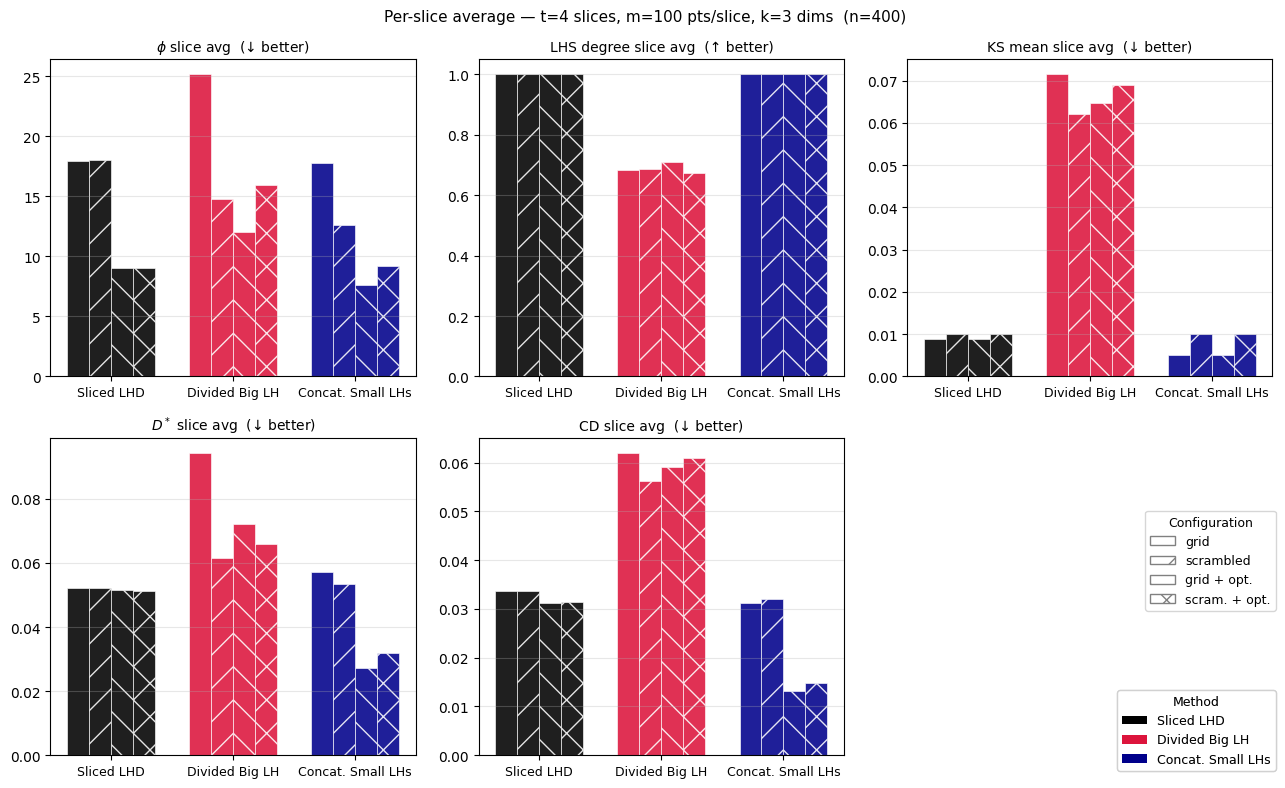

In [12]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


def _comp_stats(slices):
    X = np.vstack(slices)
    ks_full   = [s for s, _ in ks_test_uniform(X)]
    ks_slices = [[v for v, _ in ks_test_uniform(sl)] for sl in slices]
    return {
        "phi_full":         compute_phi(X, r=15),
        "lhs_full":         lhs_degree(X),
        "ks_full_mean":     float(np.mean(ks_full)),
        "d_star_full":      star_discrepancy(X),
        "cd_full":          centered_discrepancy(X),
        "phi_slice_avg":    float(np.mean([compute_phi(sl, r=15) for sl in slices])),
        "lhs_slice_avg":    float(np.mean([lhs_degree(sl) for sl in slices])),
        "ks_slice_mean":    float(np.mean([v for sub in ks_slices for v in sub])),
        "d_star_slice_avg": float(np.mean([star_discrepancy(sl) for sl in slices])),
        "cd_slice_avg":     float(np.mean([centered_discrepancy(sl) for sl in slices])),
    }


_cfg_names   = ["grid", "scrambled", "grid + opt.", "scram. + opt."]
_cfg_hatches = ["", "/", "\\", "x"]

_meth_names  = ["Sliced LHD", "Divided Big LH", "Concat. Small LHs"]
_meth_colors = {"Sliced LHD": "black", "Divided Big LH": "crimson", "Concat. Small LHs": "darkblue"}
_method_data = {
    "Sliced LHD":        [slices_big_grid, slices_big_scram, slices_big_grid_opt, slices_big_scram_opt],
    "Divided Big LH":    [div_grid,        div_scram,        div_grid_opt,        div_scram_opt],
    "Concat. Small LHs": [cat_grid,        cat_scram,        cat_grid_opt,        cat_scram_opt],
}

stats_comp = {
    meth: [_comp_stats(sl) for sl in slices_list]
    for meth, slices_list in _method_data.items()
}

_full_metrics = [
    ("phi_full",     r"$\phi$",       False),
    ("lhs_full",     "LHS degree",    True),
    ("ks_full_mean", "KS mean",       False),
    ("d_star_full",  r"$D^*$",        False),
    ("cd_full",      "CD",            False),
]
_slice_metrics = [
    ("phi_slice_avg",    r"$\phi$ slice avg",    False),
    ("lhs_slice_avg",    "LHS degree slice avg", True),
    ("ks_slice_mean",    "KS mean slice avg",    False),
    ("d_star_slice_avg", r"$D^*$ slice avg",     False),
    ("cd_slice_avg",     "CD slice avg",         False),
]

n_meths = len(_meth_names)    # 3
n_cfgs  = len(_cfg_names)     # 4
width   = 0.18
x_centers = np.arange(n_meths)   # 0, 1, 2 — one per method group

# Legend handles
_color_handles = [Patch(facecolor=_meth_colors[m], label=m) for m in _meth_names]
_hatch_handles = [
    Patch(facecolor="white", edgecolor="gray", hatch=h, label=c)
    for c, h in zip(_cfg_names, _cfg_hatches)
]

_main_title = (
    f"t={t_big} slices, m={m_big} pts/slice, k={k_big} dims  (n={t_big * m_big})"
)


def _draw_comp_fig(metrics, scope_title):
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    ax_flat = list(axes.flat)

    for ax_i, (key, ylabel, higher_better) in enumerate(metrics):
        ax = ax_flat[ax_i]
        for ci, (cfg, hatch) in enumerate(zip(_cfg_names, _cfg_hatches)):
            offset = (ci - (n_cfgs - 1) / 2) * width
            vals   = [stats_comp[meth][ci][key] for meth in _meth_names]
            ax.bar(
                x_centers + offset, vals, width=width,
                color=[_meth_colors[m] for m in _meth_names],
                hatch=hatch, edgecolor="white", linewidth=0.5, alpha=0.88,
            )
        ax.set_xticks(x_centers)
        ax.set_xticklabels(_meth_names, fontsize=9)
        direction = "↑" if higher_better else "↓"
        ax.set_title(f"{ylabel}  ({direction} better)", fontsize=10)
        ax.grid(True, axis="y", alpha=0.3)

    ax_flat[-1].set_visible(False)   # 6th panel unused

    leg1 = fig.legend(handles=_color_handles, title="Method",
                      loc="lower right", bbox_to_anchor=(0.99, 0.02),
                      fontsize=9, title_fontsize=9)
    fig.legend(handles=_hatch_handles, title="Configuration",
               loc="lower right", bbox_to_anchor=(0.99, 0.22),
               fontsize=9, title_fontsize=9)
    fig.add_artist(leg1)

    fig.suptitle(f"{scope_title} — {_main_title}", fontsize=11)
    plt.tight_layout()
    plt.show()


_draw_comp_fig(_full_metrics,  "Full design")
_draw_comp_fig(_slice_metrics, "Per-slice average")

### Scaling to Physical Bounds

`scale_LH` maps any design in $[0, 1]^k$ to a box $[l_i, u_i]$. Pass a single slice or the full list of slices — it scales all of them and returns the same structure. Use it as a final post-processing step; the LHD and sliced structure are fully preserved.

In [13]:
# Generate a small sliced design for this example
slices_unit = sliced_lhd(t=4, m=10, k=3, optimization='sa', seed=17, total_iter=50_000)

# Scale all slices at once, or a single slice — scale_LH handles both.
l_bounds = [150,  50,  10]   # temperature (°C), pressure (bar), feed rate (mm/s)
u_bounds = [300, 200, 100]

print("Bounds:", l_bounds, u_bounds)

# Whole sliced structure — returns a list of arrays with the same shapes
slices_phys = scale_LH(slices_unit, l_bounds, u_bounds)
print("All slices scaled:", [arr.shape for arr in slices_phys])
for i, (orig, phys) in enumerate(zip(slices_unit, slices_phys)):
    print(f"  Slice {i} (n={len(orig)})  min: {phys.min(axis=0).round(1)}  max: {phys.max(axis=0).round(1)}")

# Or scale a single slice — returns an ndarray
slice_phys = scale_LH(slices_unit[-1], l_bounds, u_bounds)

Bounds: [150, 50, 10] [300, 200, 100]
All slices scaled: [(10, 3), (10, 3), (10, 3), (10, 3)]
  Slice 0 (n=10)  min: [152.8  54.9  16.5]  max: [286.4 187.4  96.1]
  Slice 1 (n=10)  min: [155.9  57.6  13.7]  max: [291.9 193.4  93.6]
  Slice 2 (n=10)  min: [162.9  50.7  10.9]  max: [297.  199.4  98.8]
  Slice 3 (n=10)  min: [160.   62.9  17.4]  max: [296.2 188.8  92.2]


### Timing — Runtime vs. Size, Dimension, and Configuration

Wall-clock time for `sliced_lhd` with $t=4$ slices, sweeping the total number of points $n = t \cdot m$ from 100 to 800. Colors distinguish $k = 2, 4, 8$ dimensions; linestyles follow the same scheme as the comparison plots ($:$ grid, $--$ scrambled, $-.$ grid+optimized, $-$ scrambled+optimized). Optimized variants use `total_iter=100_000`.

In [14]:
_t_timing = 10
_n_values = [100, 200, 400]   # n = t * m; m = n // t
_k_values = [2, 4, 8]

_timing_opts = {
    "grid":                  dict(scramble=False),
    "scrambled":             dict(scramble=True),
    "grid + optimized":      dict(scramble=False, optimization="sa", total_iter=100_000),
    "scrambled + optimized": dict(scramble=True,  optimization="sa", total_iter=100_000),
}

timing_results = {}  # (k, opt_label) -> times_list
for k_t in _k_values:
    for opt_label, opt_kwargs in _timing_opts.items():
        times = []
        for n in _n_values:
            m_t = n // _t_timing
            t0 = time.perf_counter()
            sliced_lhd(t=_t_timing, m=m_t, k=k_t, seed=1, **opt_kwargs)
            times.append(time.perf_counter() - t0)
        timing_results[(k_t, opt_label)] = times
        print(f"k={k_t}, {opt_label}: {[f'{t:.3f}s' for t in times]}")

k=2, grid: ['0.002s', '0.002s', '0.005s']
k=2, scrambled: ['0.001s', '0.002s', '0.005s']
k=2, grid + optimized: ['21.184s', '18.354s', '19.865s']
k=2, scrambled + optimized: ['15.957s', '16.094s', '19.346s']
k=4, grid: ['0.003s', '0.003s', '0.009s']
k=4, scrambled: ['0.002s', '0.003s', '0.010s']
k=4, grid + optimized: ['14.114s', '17.842s', '20.153s']
k=4, scrambled + optimized: ['15.581s', '17.083s', '19.581s']
k=8, grid: ['0.004s', '0.006s', '0.018s']
k=8, scrambled: ['0.003s', '0.006s', '0.018s']
k=8, grid + optimized: ['16.480s', '16.660s', '21.005s']
k=8, scrambled + optimized: ['14.480s', '17.940s', '26.172s']


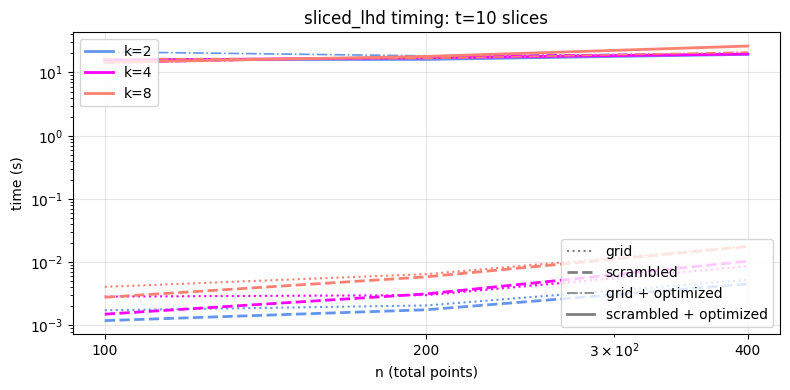

In [15]:
from matplotlib.lines import Line2D

_k_colors = ["cornflowerblue", "magenta", "salmon"]
_opt_ls = {
    "grid":                  ":",
    "scrambled":             "--",
    "grid + optimized":      "-.",
    "scrambled + optimized": "-",
}
_opt_lw = {":": 1.5, "--": 2.0, "-.": 1.2, "-": 2.0}

fig, ax = plt.subplots(figsize=(8, 4))
for (k_t, opt_label), times in timing_results.items():
    ls = _opt_ls[opt_label]
    ax.plot(_n_values, times,
            color=_k_colors[_k_values.index(k_t)], ls=ls, lw=_opt_lw[ls])

color_handles = [Line2D([0],[0], color=c, lw=2, label=f"k={k}") for k, c in zip(_k_values, _k_colors)]
ls_handles = [
    Line2D([0],[0], color="gray", lw=_opt_lw[":"],  ls=":",  label="grid"),
    Line2D([0],[0], color="gray", lw=_opt_lw["--"], ls="--", label="scrambled"),
    Line2D([0],[0], color="gray", lw=_opt_lw["-."], ls="-.", label="grid + optimized"),
    Line2D([0],[0], color="gray", lw=_opt_lw["-"],  ls="-",  label="scrambled + optimized"),
]
leg1 = ax.legend(handles=color_handles, loc="upper left")
ax.add_artist(leg1)
ax.legend(handles=ls_handles, loc="lower right")

ax.set_xlabel("n (total points)")
ax.set_ylabel("time (s)")
ax.set_title(f"sliced_lhd timing: t={_t_timing} slices")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xticks(_n_values); ax.set_xticklabels(_n_values)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()